# Introduction to Artificial Neural Networks

**OBJECTIVES**

- Understand connections between linear models and neural networks
- Use `pytorch` to build basic multilayer perceptron models for regression and classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

Please use the form [here](https://forms.gle/dHk5F14FYBJwWXtg6) to discuss your time series problem and final project ideas.

## Regression Revisited

In [385]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [386]:
def f(x): return torch.sin(x)

In [387]:
x = torch.linspace(-3, 3, 500)

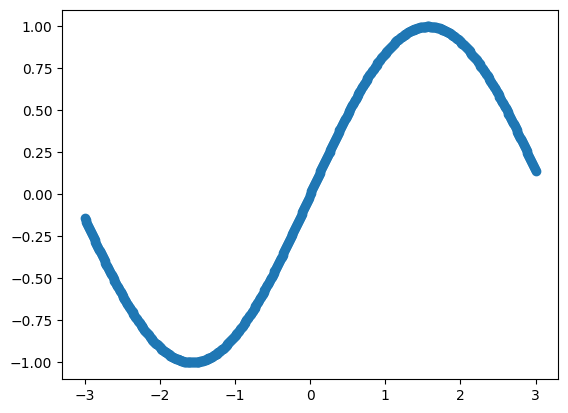

In [388]:
plt.plot(x, f(x), 'o')

In [389]:
model = nn.Sequential(nn.Linear(1, 1000), nn.ReLU(), nn.Linear(1000, 1))
optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss = nn.MSELoss()

In [390]:
x.unsqueeze(-1).shape

torch.Size([500, 1])

In [391]:
y = f(x)

In [392]:
x

tensor([-3.0000, -2.9880, -2.9760, -2.9639, -2.9519, -2.9399, -2.9279, -2.9158,
        -2.9038, -2.8918, -2.8798, -2.8677, -2.8557, -2.8437, -2.8317, -2.8196,
        -2.8076, -2.7956, -2.7836, -2.7715, -2.7595, -2.7475, -2.7355, -2.7234,
        -2.7114, -2.6994, -2.6874, -2.6754, -2.6633, -2.6513, -2.6393, -2.6273,
        -2.6152, -2.6032, -2.5912, -2.5792, -2.5671, -2.5551, -2.5431, -2.5311,
        -2.5190, -2.5070, -2.4950, -2.4830, -2.4709, -2.4589, -2.4469, -2.4349,
        -2.4228, -2.4108, -2.3988, -2.3868, -2.3747, -2.3627, -2.3507, -2.3387,
        -2.3267, -2.3146, -2.3026, -2.2906, -2.2786, -2.2665, -2.2545, -2.2425,
        -2.2305, -2.2184, -2.2064, -2.1944, -2.1824, -2.1703, -2.1583, -2.1463,
        -2.1343, -2.1222, -2.1102, -2.0982, -2.0862, -2.0741, -2.0621, -2.0501,
        -2.0381, -2.0261, -2.0140, -2.0020, -1.9900, -1.9780, -1.9659, -1.9539,
        -1.9419, -1.9299, -1.9178, -1.9058, -1.8938, -1.8818, -1.8697, -1.8577,
        -1.8457, -1.8337, -1.8216, -1.80

In [393]:
model(x.unsqueeze(-1))[:5]

tensor([[0.5644],
        [0.5644],
        [0.5643],
        [0.5643],
        [0.5643]], grad_fn=<SliceBackward0>)

In [394]:
y.shape, yhat.shape, y.unsqueeze(-1).shape

(torch.Size([500]), torch.Size([569, 1]), torch.Size([500, 1]))

In [395]:
losses = []
for epoch in range(5000):
    yhat = model(x.unsqueeze(-1))
    loss_fn = loss(y.unsqueeze(-1), yhat)
    optimizer.zero_grad()
    loss_fn.backward()
    optimizer.step()
    losses.append(loss_fn.item())

In [396]:
yhat[:5]

tensor([[-0.2903],
        [-0.2967],
        [-0.3032],
        [-0.3096],
        [-0.3160]], grad_fn=<SliceBackward0>)

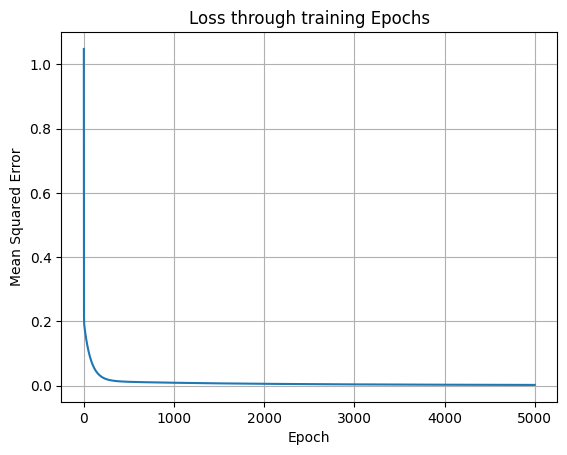

In [397]:
plt.plot(losses)
plt.title('Loss through training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid();

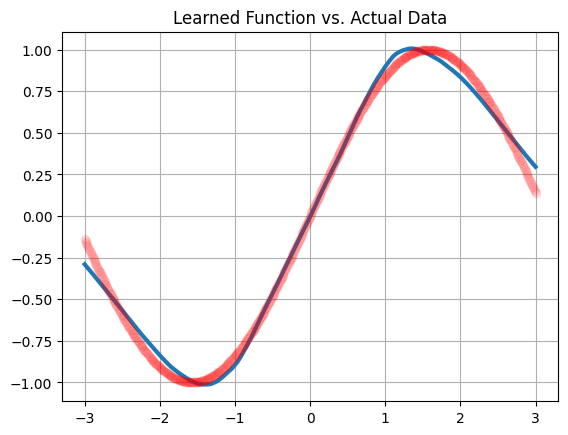

In [398]:
plt.plot(x, model(x.unsqueeze(-1)).detach().numpy(), linewidth = 3)
plt.plot(x, y, 'ro', alpha = 0.1)
plt.title('Learned Function vs. Actual Data')
plt.grid();

What we see here is an example of the **Universal Approximation Theorem** and our first example of an artificial neural network.  [Wikipedia](https://en.wikipedia.org/wiki/Universal_approximation_theorem)

## Linear Models Revisited

Recall our logistic regression model.  We can think about this model as a linear function composed into the sigmoid function.

$$l(x) = \beta_0 + \beta_1 X$$
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

$$\text{Logistic Model} = \sigma(l(x))$$

![](images/linear_sep.png)

We also understodd the quality of the model minimizing a loss function -- log loss.  This is also called **binary cross entropy**, and the "best" model was the one whose parameters minimized the log loss or BCE.  Together, we have two important ideas -- a linear function and the goal of minimizing a loss function.  Linear regression is a similar algorithm with a different loss function -- Mean Squared Error.

### Minimizing Functions

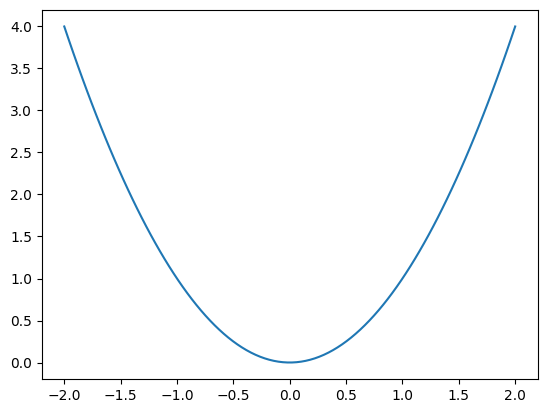

In [109]:
x = torch.linspace(-2, 2, 100)
def f(x): return x**2
plt.plot(x, f(x));

In [110]:
def df(x): return 2*x

In [114]:
def tan_line(x, a): return df(a)*(x - a) + f(a)

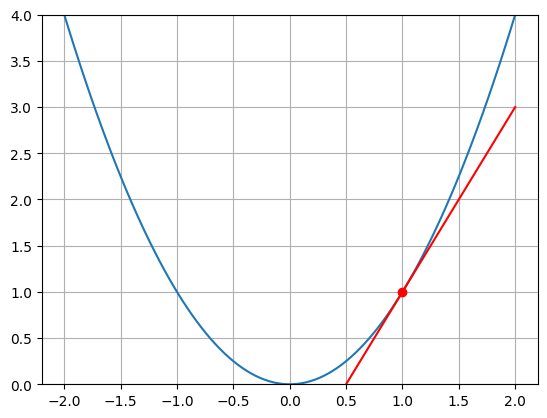

In [116]:
plt.plot(x, f(x))
plt.plot(x, tan_line(x, 1), 'r')
plt.plot(1, f(1), 'ro')
plt.ylim(0, 4)
plt.grid();

In [134]:
x0 = 1
step_size = 0.1

In [135]:
x1 = x0 - step_size*df(x0)

In [136]:
x1

0.8

In [137]:
x2 = x1 - step_size*df(x1)
x2

0.64

In [138]:
xs = [x0]
for i in range(100):
    xnext = xs[-1] - step_size*df(xs[-1])
    xs.append(xnext)
xs = np.array(xs)

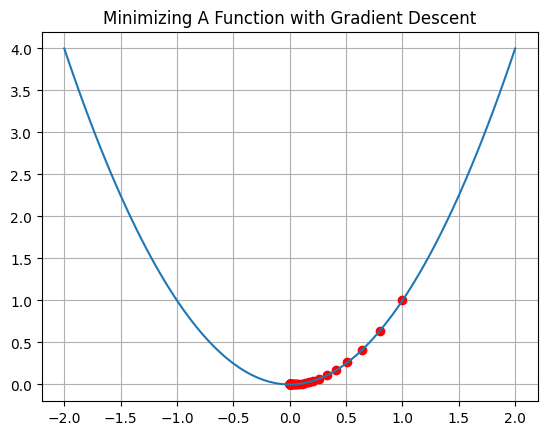

In [141]:
plt.plot(xs, f(xs), 'ro')
plt.plot(x, f(x))
plt.grid()
plt.title('Minimizing A Function with Gradient Descent');

### A Visual Example

- [Tensorflow Playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=1&seed=0.79501&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

In [303]:
from sklearn.datasets import load_breast_cancer

In [379]:
cancer = load_breast_cancer()
X, Y = cancer.data, cancer.target

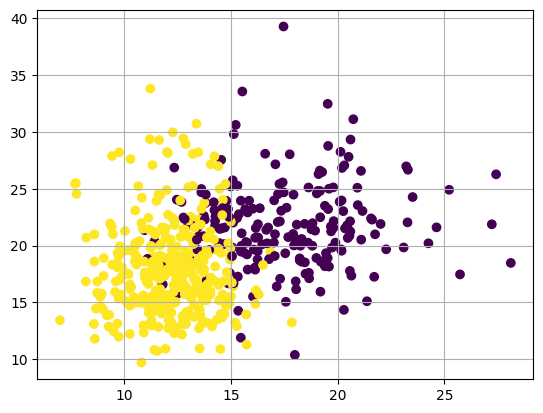

In [380]:
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.grid();

In [381]:
l1 = nn.Linear(in_features=30, out_features = 100)

In [382]:
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.float32)

In [383]:
l1(X)[0]

tensor([  23.6913,   79.8806, -264.8895,   86.6454,  184.6571, -478.5456,
         -71.5017, -315.2294, -259.5677, -235.2671,    5.0943,  301.7432,
         176.5565, -139.8545,  138.5058, -355.6392,  -84.3386, -440.7909,
         194.5602, -332.8313, -362.3071,  210.6747,   59.2030,  467.0563,
         120.8150,  472.7196,  121.4425, -113.7389, -166.0539, -333.7622,
         206.2944, -402.4569,  276.0428,  -62.9335, -374.9991,  -13.6699,
         521.1909, -480.2935,   11.7878, -235.7927,   90.6675,  335.1009,
        -238.4158, -236.5206,  120.4615,   61.8277, -107.8010,  143.2649,
         260.4332,  -96.2766,  335.5218, -109.6438,    5.9979, -413.1613,
         229.7469, -150.1314,  462.1651,  413.3831,  207.9962,  -89.5430,
        -155.4217,  269.5447,  235.0949, -159.0285,  383.7048, -342.7009,
         222.2795,  215.5688,  -93.2076, -363.5149,  179.7176, -503.1702,
         503.0753,  -46.1244,  261.4064,  464.0982,  101.1189, -347.2296,
        -114.1725,  135.8859,  300.345

In [333]:
list(l1.parameters())

[Parameter containing:
 tensor([[ 0.0461,  0.1466,  0.0335,  ...,  0.0720, -0.0554, -0.1565],
         [ 0.0602, -0.1323,  0.1103,  ..., -0.0801,  0.1705,  0.0726],
         [-0.0117,  0.1725, -0.0983,  ..., -0.1214,  0.1722,  0.0522],
         ...,
         [ 0.0923,  0.0484, -0.0076,  ...,  0.1557,  0.0838, -0.1801],
         [-0.1420, -0.0284, -0.1030,  ..., -0.1816,  0.0290,  0.1678],
         [ 0.1252,  0.0861,  0.0958,  ...,  0.0466, -0.1793,  0.0086]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.1819,  0.1250,  0.0368,  0.1341,  0.0254,  0.1350, -0.0618,  0.1179,
          0.1283, -0.1765, -0.1070, -0.0900, -0.1737, -0.0711,  0.0129, -0.1362,
          0.0964, -0.1204, -0.0918, -0.1818, -0.1104,  0.1630,  0.0734,  0.0911,
         -0.0352,  0.0076, -0.0943,  0.0249, -0.0682,  0.0521, -0.1775,  0.1571,
          0.1815,  0.1232, -0.0209,  0.0370, -0.1156, -0.1765, -0.1076,  0.0628,
          0.0368, -0.0636, -0.1729, -0.0209, -0.0701, -0.1206,  0.0267, -0.0175

In [334]:
activation = nn.ReLU()

In [335]:
output_1 = activation(l1(X))

In [336]:
l2 = nn.Linear(in_features=100, out_features=1)

In [337]:
output_2 = l2(output_1)

In [338]:
output_2[:10]

tensor([[15.7168],
        [ 9.1403],
        [ 8.6870],
        [ 4.3181],
        [ 7.4469],
        [ 4.9296],
        [ 8.3336],
        [ 5.7261],
        [ 4.4716],
        [ 3.9067]], grad_fn=<SliceBackward0>)

In [339]:
output_activation = nn.Sigmoid()

In [340]:
yhat = output_activation(output_2)

In [341]:
yhat.shape

torch.Size([569, 1])

In [342]:
loss = nn.BCELoss()

In [343]:
loss(Y.unsqueeze(-1), yhat)

tensor(39.4904, grad_fn=<BinaryCrossEntropyBackward0>)

### Training the Model

*Ingredients*:

- Model: We will build this with either `nn.Sequential` or by subclassing the `nn.Module`.
- Loss Function: Depending on the task this will be different
    -   Regression is `nn.MSELoss`
    -   Binary classification is `nn.BCELoss`
    -   Multi-class classification is `nn.CrossEntropyLoss`
- Optimizer: Function to minimize the loss -- today we will use `optim.SGD`

In [344]:
model = nn.Sequential(nn.Linear(30, 100),
                      nn.ReLU(),
                      nn.Linear(100, 1),
                      nn.Sigmoid())

In [345]:
loss_fn = nn.BCELoss()

In [346]:
optimizer = optim.SGD(model.parameters(), lr = 0.05)

In [347]:
yhat = model(X)

In [349]:
loss = loss_fn(yhat, Y.unsqueeze(-1))

In [350]:
optimizer.zero_grad()

In [351]:
loss.backward()

In [352]:
optimizer.step()

In [353]:
X.shape

torch.Size([569, 30])

In [354]:
X = (X - X.mean())/X.std()

In [355]:
losses = []
for epoch in range(1000):
    yhat = model(X)
    loss = loss_fn(yhat, Y.unsqueeze(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

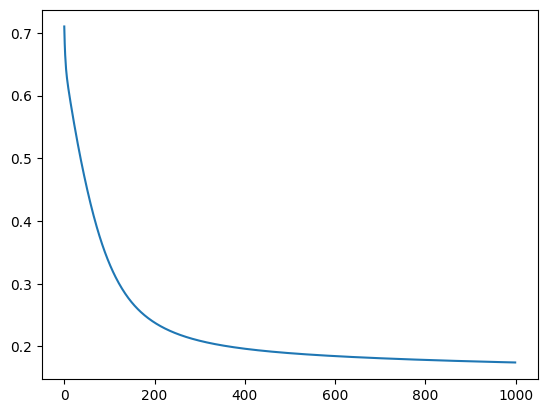

In [356]:
plt.plot(losses)

### Making Predictions

The model returns probabilites that we need to use in order to make predictions.

In [357]:
yhat = model(X)

In [358]:
preds = torch.where(yhat > .5, 1, 0)

In [360]:
(preds.squeeze(-1) == Y).sum()/len(Y)

tensor(0.9227)

#### Example: Handwritten Digits

Below, the handwritten digits data is loaded and transformed to `torch.tensor` objects.  Recall these are 8 x 8 images of handwritten digits, and there are ten categories to predict.

In [366]:
from sklearn.datasets import load_digits

In [367]:
digits = load_digits()

In [368]:
X, y = digits.data, digits.target

In [369]:
X = (X - X.mean())/X.std()

In [370]:
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(y, dtype = torch.float32)

In [371]:
X.shape

torch.Size([1797, 64])

#### Problem

Below, build a model with the following:

- A Linear layer with 100 neurons
- A ReLU activation on this layer
- A Linear layer with another 100 neurons
- A ReLU activation on this layer
- A Linear output layer with 10 neurons

Use the `optim.SGD` to optimize the parameters of the model.

Use `nn.CrossEntropyLoss` as your loss function for multiclass classification.

In [372]:
model = ''

In [373]:
optimizer = ''

In [374]:
loss_fn = ''

In [375]:
from tqdm import tqdm

In [376]:
def train_function(model, X, Y, epochs, optimizer, loss_fn, losses = []):
    '''
    The function trains a pytorch model given a model,
    number of training epochs, optimizer, and loss function.
    It returns a list of losses from training.
    '''
    for epoch in tqdm(range(epochs)):
        yhat = model(X)
        loss = loss_fn(yhat, Y.unsqueeze(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

In [377]:
train_function(model, X, Y, epochs = 1000, optimizer = optimizer, loss_fn = loss_fn)

  0%|                                                  | 0/1000 [00:00<?, ?it/s]


TypeError: 'str' object is not callable

In [ ]:
yhat = model(X)
predictions = torch.argmax(yhat)
sum(predictions == Y)/len(Y)